In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
IMG_SIZE=256
BATCH_SIZE=32
CHANNEL=3
EPOCH=50

In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset) #because we set batch size of 32

68

In [6]:
for image,label in dataset:
    print(image.shape)

(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 256, 3)
(32, 256, 

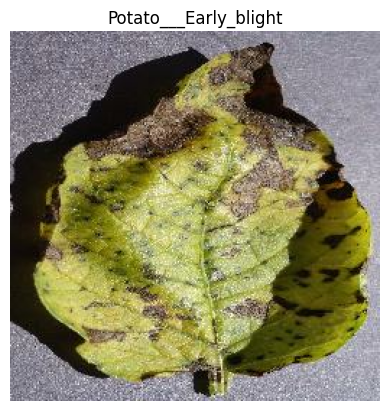

In [7]:
for image,label in dataset:
    plt.imshow(image[0].numpy().astype('uint8'))
    plt.title(class_names[label[0]])
    plt.axis('off')

In [8]:
#splitting dataset
#80 percent for training and remaining 20% in that 10 is for validation and remaining 10 is for testing 
train_size=0.8
val_size=0.1
test_size=0.1
len(dataset)*train_size

54.400000000000006

In [9]:
train_dataset=dataset.take(54)
len(train_dataset)

54

In [10]:
test_dataset=dataset.skip(54) #skipping first 54
len(test_dataset)

14

In [11]:
len(dataset)*val_size

6.800000000000001

In [12]:
val_dataset=test_dataset.take(6)
len(val_dataset)

6

In [13]:
test_dataset=test_dataset.skip(6)
len(test_dataset)

8

In [14]:
#let us create a function to split the dataset intead of manually spiliting it as we did aboive
def split_dataset(dataset,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=1000):
    ds=len(dataset)
    if shuffle:
        dataset=dataset.shuffle(shuffle_size,seed=12)
    train_size=int(ds*train_split)
    val_size=int(ds*val_split)
    test_size=int(ds*test_split)

    train_ds=dataset.take(train_size)
    val_ds=dataset.skip(train_size).take(val_size)
    test_ds=dataset.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds

In [15]:
train_ds,val_ds,test_ds=split_dataset(dataset)
len(train_ds),len(val_ds),len(test_ds)

(54, 6, 8)

In [16]:
for image,label in train_ds.take(1):
    print(image.shape)
    print(label)

(32, 256, 256, 3)
tf.Tensor([0 1 2 1 1 2 1 2 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 1 0 0 1 1 0 1 1 0], shape=(32,), dtype=int32)


In [17]:
dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [18]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
#scaling we divide rgb image pixels by 255 adn resizing image just in case if user inputs another size image
resize_rescale=tf.keras.Sequential([
    layers.Resizing(IMG_SIZE,IMG_SIZE),
    layers.Rescaling(1.0/255)
])
#these all come under preprocessing and data pipeline

In [20]:
#this also comes under preprocesing, this is data agumentation, (we are doing a geometric data agumentation)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

In [21]:
print(models)
print(type(models))

<module 'keras.models' from 'c:\\Users\\tani\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\keras\\models\\__init__.py'>
<class 'module'>


In [22]:
model_1=keras.Sequential([
    resize_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,CHANNEL)),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(3,activation='softmax')
])

c:\Users\tani\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model_1.build((None,256,256,3))

In [24]:
#let us use the knowledge of transfer learning and use predefined resnet50 model
from tensorflow.keras.applications import ResNet50

base_model=ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)
base_model.trainable=False

In [25]:
print(len(base_model.layers))

175


In [26]:
from tensorflow.keras.applications.resnet50 import preprocess_input
preprocess = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE,IMG_SIZE),
    layers.Lambda(preprocess_input)
])

In [27]:
model_2 = keras.Sequential([
    preprocess,
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

In [28]:
model_2.build((None,256,256,3))

In [29]:
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
model_1.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [32]:
history=model_1.fit(
    train_ds,
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.4836 - loss: 0.8939 - val_accuracy: 0.5104 - val_loss: 0.8192
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6590 - loss: 0.6826 - val_accuracy: 0.6615 - val_loss: 0.6488
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7893 - loss: 0.4900 - val_accuracy: 0.8333 - val_loss: 0.3878
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8680 - loss: 0.3408 - val_accuracy: 0.9010 - val_loss: 0.2521
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8609 - loss: 0.3355 - val_accuracy: 0.8854 - val_loss: 0.2698
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8938 - loss: 0.2537 - val_accuracy: 0.9062 - val_loss: 0.2414
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8820 - loss: 0.2789 - val_accuracy: 0.9219 - val_loss: 0.3177
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9225 - loss: 0.2238 - val_accuracy: 0.8698 - val_loss:

In [33]:
score=model_1.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 326ms/step - accuracy: 0.9961 - loss: 0.0205


In [34]:
#lets do the same thing for model_2
model_2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [35]:
history_2=model_2.fit(
    train_ds,
    epochs=10,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.9184 - loss: 0.2188 - val_accuracy: 0.9583 - val_loss: 0.0864
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.9730 - loss: 0.0711 - val_accuracy: 0.9792 - val_loss: 0.0603
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.9847 - loss: 0.0469 - val_accuracy: 0.9948 - val_loss: 0.0368
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.9900 - loss: 0.0289 - val_accuracy: 0.9948 - val_loss: 0.0298
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.9888 - loss: 0.0358 - val_accuracy: 0.9844 - val_loss: 0.0364
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.9865 - loss: 0.0366 - val_accuracy: 0.9583 - val_loss: 0.0973
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.9824 - loss: 0.0431 - val_accuracy: 0.9948 - val_loss: 0.0257
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.9935 - loss: 0.0180 - val_accuracy: 0.9792 - v

In [36]:
score_2=model_2.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 1.0000 - loss: 0.0066


In [37]:
history

In [38]:
history.params,history.history.keys()

({'verbose': 1, 'epochs': 50, 'steps': 54},
 dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss']))

In [39]:
history.history['val_accuracy']

[0.5104166865348816,
 0.6614583134651184,
 0.8333333134651184,
 0.9010416865348816,
 0.8854166865348816,
 0.90625,
 0.921875,
 0.8697916865348816,
 0.953125,
 0.953125,
 0.8333333134651184,
 0.9583333134651184,
 0.9114583134651184,
 0.9375,
 0.9739583134651184,
 0.9375,
 0.9583333134651184,
 0.9270833134651184,
 0.875,
 0.9583333134651184,
 0.9322916865348816,
 0.9635416865348816,
 0.9791666865348816,
 0.9635416865348816,
 0.9583333134651184,
 0.96875,
 0.953125,
 0.9739583134651184,
 0.96875,
 0.9583333134651184,
 0.9895833134651184,
 0.9322916865348816,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.9739583134651184,
 0.96875,
 0.96875,
 0.9947916865348816,
 0.9895833134651184,
 0.984375,
 0.9895833134651184,
 1.0,
 1.0,
 0.9895833134651184,
 0.9739583134651184,
 0.9947916865348816,
 0.984375,
 0.9947916865348816]

In [40]:
#lets plot some graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

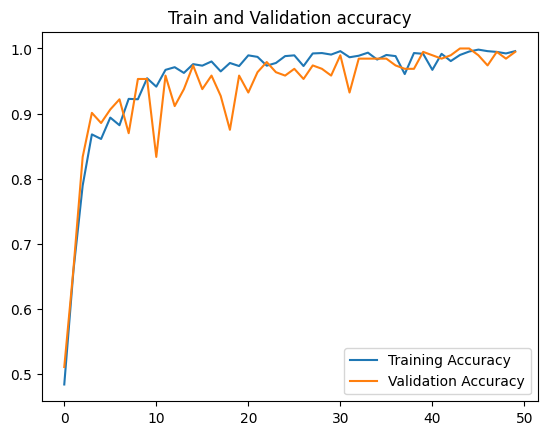

In [41]:
plt.plot(range(EPOCH),acc,label='Training Accuracy')
plt.plot(range(EPOCH),val_acc,label='Validation Accuracy')
plt.title("Train and Validation accuracy")
plt.legend()
plt.show()

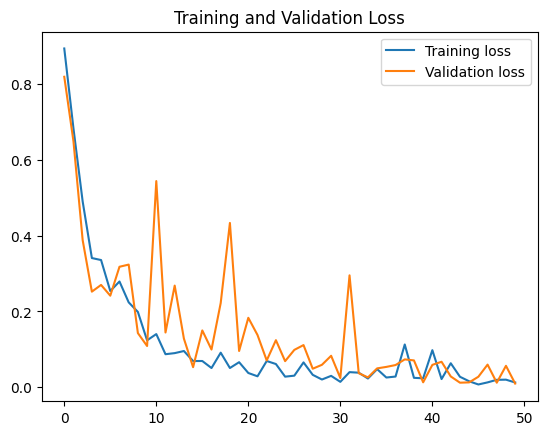

In [42]:
plt.plot(range(EPOCH),loss,label='Training loss')
plt.plot(range(EPOCH),val_loss,label="Validation loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

first image to predict
first image actual label Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
Predicted label Potato___Early_blight
confidence is  100.0


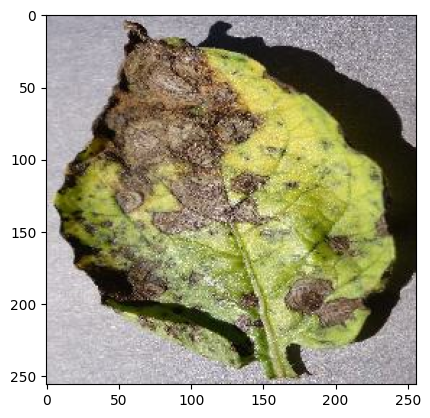

In [43]:
for image,label in test_ds.take(1):
    first_img=(image[0].numpy().astype('uint8'))
    first_label=label[0].numpy()
    print("first image to predict")
    plt.imshow(first_img)
    print("first image actual label",class_names[first_label])
    pred=model_1.predict(image)
    print("Predicted label",class_names[np.argmax(pred[0])])
    confidence=np.round(100*(np.max(pred[0])))
    print("confidence is ",confidence)

first image to predict
first image actual label Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted label Potato___Late_blight
confidence is  100.0


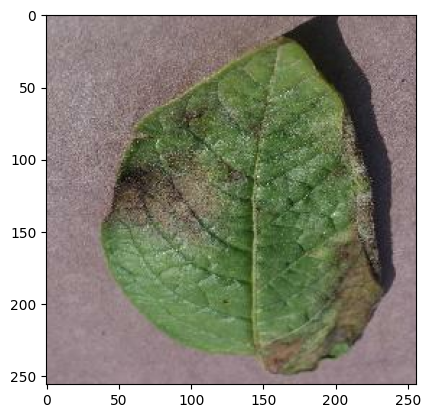

In [44]:
for image,label in test_ds.take(1):
    first_img=(image[0].numpy().astype('uint8'))
    first_label=label[0].numpy()
    print("first image to predict")
    plt.imshow(first_img)
    print("first image actual label",class_names[first_label])
    pred=model_2.predict(image)
    print("Predicted label",class_names[np.argmax(pred[0])])
    confidence=np.round(100*(np.max(pred[0])))
    print("confidence is ",confidence)

In [45]:
#cleary our predefined (transfer learning) resnet50 is working perfectly with the prediction,our custom cnn is also working good but for one input it failed to predict the correct label

In [46]:
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [47]:
model_version=1
model_1.save("../models/1.keras")